In [43]:
%pip install pymysql
%pip install mysql-connector-python pandas
%pip install SQLAlchemy
%pip install load_dotenv
%pip install pandas
%pip install matplotlib
%pip install ipython-sql
%pip install scipy

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Set up database

In [44]:
from dotenv import load_dotenv
import os

load_dotenv()

user = os.getenv("DB_USER")
password = os.getenv("DB_PASS")
host = os.getenv("DB_HOST")
dbname = os.getenv("DB_NAME")

from sqlalchemy import create_engine
engine = create_engine(f"mysql+mysqlconnector://{user}:{password}@{host}/{dbname}", connect_args={'init_command': 'SET time_zone="+07:00"'})

# PHONE SCREEN

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sqlalchemy import create_engine, text

In [46]:
query = "SELECT * FROM minutes_per_day"
df = pd.read_sql(query, engine)

In [47]:
df.head()

,DAY_ID,minutes
0,1,0.0
1,2,0.0
2,3,0.0
3,4,0.0
4,5,160.0


In [48]:
print(df[['minutes']].describe())

          minutes
count   24.000000
mean    35.916667
std     58.382484
min      0.000000
25%      0.000000
50%      0.000000
75%     60.000000
max    175.000000


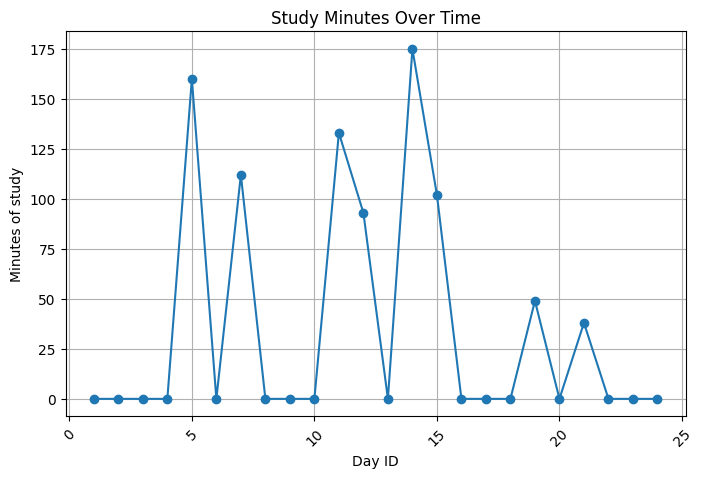

In [49]:
plt.figure(figsize=(8, 5))
plt.plot(df['DAY_ID'], df['minutes'], marker='o')
plt.xlabel('Day ID')
plt.ylabel('Minutes of study')
plt.title('Study Minutes Over Time')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [50]:
df['growth_rate (%)'] = (
    df['minutes']
    .replace(0, pd.NA)     # Treat 0 as missing
    .pct_change() * 100
)

df['growth_rate (%)'] = df['growth_rate (%)'].replace([np.inf, -np.inf], pd.NA).fillna(0)

print(df[['growth_rate (%)']].round(2))

    growth_rate (%)
0              0.00
1              0.00
2              0.00
3              0.00
4              0.00
5              0.00
6            -30.00
7              0.00
8              0.00
9              0.00
10            18.75
11           -30.08
12             0.00
13            88.17
14           -41.71
15             0.00
16             0.00
17             0.00
18           -51.96
19             0.00
20           -22.45
21             0.00
22             0.00
23             0.00


/var/folders/20/3dpkl8y92xs2mr9bxxsnt9j40000gn/T/ipykernel_20709/4082176074.py:4: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change() * 100


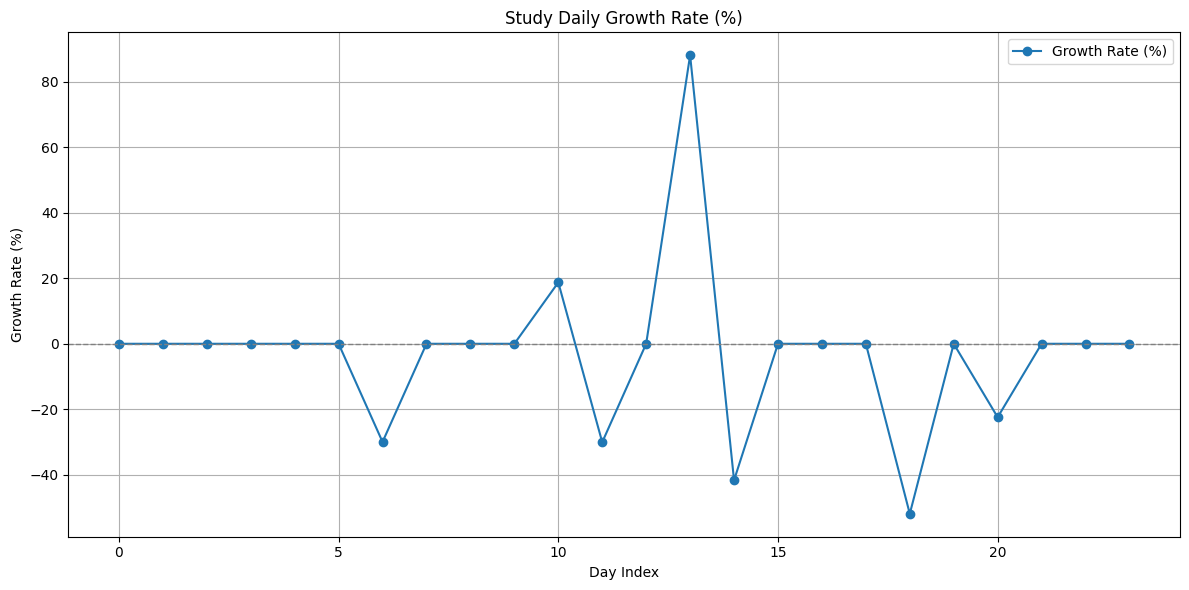

In [ ]:
df['growth_rate (%)'] = df['growth_rate (%)'].round(2)

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['growth_rate (%)'], marker='o', linestyle='-', label='Growth Rate (%)')

plt.axhline(0, color='gray', linestyle='--', linewidth=1)

plt.title('Study Daily Growth Rate (%)')
plt.xlabel('Day Index')
plt.ylabel('Growth Rate (%)')
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

In [51]:
valid_minutes = df['minutes'].replace(0, pd.NA).dropna()

if not valid_minutes.empty:
    initial = valid_minutes.iloc[0]
    final = valid_minutes.iloc[-1]
    overall_growth = ((final - initial) / initial) * 100
    print(f"Overall growth rate from start to end: {overall_growth:.2f}%")
else:
    print("Not enough valid data to calculate growth.")

Overall growth rate from start to end: -76.25%


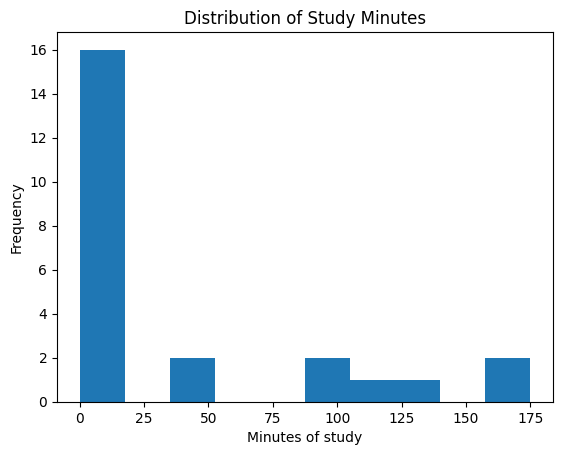

In [52]:
df['minutes'].plot.hist()
plt.xlabel("Minutes of study")
plt.title("Distribution of Study Minutes")
plt.show()